# axSpA Radiographic Classification — Publication Analysis (ROC, AUC, Eigen-CAM)

**Model:** YOLO11l-cls dla różnicowania zmian zwyrodnieniowych vs axSpA na zdjęciach kręgosłupa.

**Klasy (ordinal continuum):**
- Grade 0 = Normal
- Grade 1 = Osteophytes
- Grade 2 = Parasyndesmophytes
- Grade 3 = Syndesmophytes

**Workflow:** Upload `best.pt` → Upload data ZIP → Inference → Wszystkie statystyki, figury i Eigen-CAM dla paperu → Download wszystkiego jako ZIP.

Notebook w konwencji `sacroiliitis_colab_analysis_v2`.


## Step 1 — Install dependencies

In [ ]:
!pip install -q ultralytics grad-cam scikit-learn matplotlib seaborn pandas numpy scipy
!pip install -q opencv-python-headless

import torch
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 54.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 46.1 MB/s eta 0:00:00
PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## Step 2 — Upload your model file (best.pt)

In [ ]:
from google.colab import files
import os

print('Upload your best.pt file (the trained YOLO11x-cls model):')
uploaded = files.upload()

model_path = list(uploaded.keys())[0]
print(f'\nModel uploaded: {model_path}')
print(f'Size: {os.path.getsize(model_path) / 1e6:.1f} MB')

Upload your best.pt file (the trained YOLO11x-cls model):


Saving best.pt to best.pt

Model uploaded: best.pt
Size: 26.0 MB


## Step 3 — Upload test images (as ZIP)

Wymagana struktura wewnątrz ZIP:
```
val/
  normal/         *.jpg/*.png
  osteofity/      *.jpg/*.png
  parasyndesmofity/  *.jpg/*.png
  syndesmofity/   *.jpg/*.png
test/
  (te same 4 podfoldery)
```


In [ ]:
import zipfile
import shutil

print('Upload your data.zip file:')
uploaded = files.upload()

zip_path = list(uploaded.keys())[0]
extract_dir = '/content/test_data'

if os.path.exists(extract_dir):
    shutil.rmtree(extract_dir)
os.makedirs(extract_dir)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Auto-detect: check current dir, then walk one level deeper if needed
def find_data_root(base_dir):
    """Find directory containing val/test folders, walk down if needed."""
    valid_split_names = {'val', 'test', 'internal', 'external', 'center1', 'center2', 'wewnetrzny', 'zewnetrzny'}

    items = os.listdir(base_dir)
    found_splits = [d for d in items if d.lower() in valid_split_names
                    and os.path.isdir(os.path.join(base_dir, d))]
    if found_splits:
        return base_dir, found_splits

    for item in items:
        sub_path = os.path.join(base_dir, item)
        if os.path.isdir(sub_path):
            sub_items = os.listdir(sub_path)
            found_splits = [d for d in sub_items if d.lower() in valid_split_names
                           and os.path.isdir(os.path.join(sub_path, d))]
            if found_splits:
                return sub_path, found_splits

    return base_dir, []

extract_dir, found_splits = find_data_root(extract_dir)
print(f'\nData directory: {extract_dir}')
print(f'Found splits: {found_splits}')

# Map user's split names to internal/external roles
INTERNAL_ALIASES = {'val', 'internal', 'wewnetrzny', 'center1'}
EXTERNAL_ALIASES = {'test', 'external', 'zewnetrzny', 'center2'}

internal_split = next((s for s in found_splits if s.lower() in INTERNAL_ALIASES), None)
external_split = next((s for s in found_splits if s.lower() in EXTERNAL_ALIASES), None)

print(f'\nInternal validation folder: {internal_split}')
print(f'External test folder: {external_split}')

# Verify and count images
for role, split in [('Internal validation', internal_split), ('External test', external_split)]:
    if split is None:
        print(f'\n[WARNING] {role} folder not found!')
        continue
    split_path = os.path.join(extract_dir, split)
    print(f'\n{role} ({split}/):')
    total = 0
    for cls in sorted(os.listdir(split_path)):
        cls_path = os.path.join(split_path, cls)
        if os.path.isdir(cls_path):
            n_imgs = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            print(f'  {cls}/: {n_imgs} images')
            total += n_imgs
    print(f'  TOTAL: {total} images')

Upload your data.zip file:


Saving data.zip to data.zip

Data directory: /content/test_data
Found splits: ['val', 'test']

Internal validation folder: val
External test folder: test

Internal validation (val/):
  normal/: 37 images
  osteofity/: 34 images
  parasyndesmofity/: 12 images
  syndesmofity/: 12 images
  TOTAL: 95 images

External test (test/):
  normal/: 55 images
  osteofity/: 54 images
  parasyndesmofity/: 20 images
  syndesmofity/: 21 images
  TOTAL: 150 images


## Step 4 — Load YOLO11l-cls model

In [ ]:
from ultralytics import YOLO

model = YOLO(model_path)
model.to('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Model loaded successfully')
print(f'Number of classes: {len(model.names)}')
print(f'Class names: {model.names}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Model loaded successfully
Number of classes: 4
Class names: {0: 'normal', 1: 'osteofity', 2: 'parasyndesmofity', 3: 'syndesmofity'}


## Step 5 — Inference time benchmark

In [ ]:
import time
import os
import numpy as np
import torch

# Ten krok wymaga: (a) załadowanego modelu z Kroku 4 [zmienna `model`],
#                  (b) rozpakowanych obrazów z Kroku 3 [zmienna `extract_dir`].
# Jeżeli chcesz uruchomić Krok 5 SAMODZIELNIE bez unzipa całego ZIPa,
# ustaw poniżej ścieżkę do folderu z jakimikolwiek testowymi obrazami.

# Automatycznie znajdź folder z obrazami testowymi
IMG_FOLDER = None
try:
    # Preferuj external test set jeśli został zdefiniowany
    IMG_FOLDER = os.path.join(extract_dir, external_split)
except NameError:
    # Fallback: pierwszy folder z obrazami w /content
    for root, dirs, files in os.walk('/content'):
        image_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if len(image_files) >= 5:
            IMG_FOLDER = root
            break

if IMG_FOLDER is None or not os.path.isdir(IMG_FOLDER):
    raise FileNotFoundError('Nie znaleziono folderu z obrazami. Uruchom najpierw Step 3 (Upload ZIP).')

print(f'Using image folder: {IMG_FOLDER}')
print('Benchmarking inference time (50 images, warm-up + measurement)...\n')

# Zbierz do 50 przykładowych obrazów (rekurencyjnie)
sample_imgs = []
for root, dirs, files in os.walk(IMG_FOLDER):
    for f in sorted(files):
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            sample_imgs.append(os.path.join(root, f))
        if len(sample_imgs) >= 50:
            break
    if len(sample_imgs) >= 50:
        break
sample_imgs = sample_imgs[:50]
print(f'Collected {len(sample_imgs)} sample images.')

# Warm-up (5 predykcji, nie liczone)
print('Warmup (5 runs)...')
for p in sample_imgs[:5]:
    _ = model(p, verbose=False)

# Właściwy pomiar
print(f'Measuring ({len(sample_imgs)} runs)...')
times = []
for p in sample_imgs:
    t0 = time.perf_counter()
    _ = model(p, verbose=False)
    times.append(time.perf_counter() - t0)

inf_summary = {
    'n_images': len(times),
    'mean_ms': float(np.mean(times) * 1000),
    'sd_ms': float(np.std(times) * 1000),
    'median_ms': float(np.median(times) * 1000),
    'min_ms': float(np.min(times) * 1000),
    'max_ms': float(np.max(times) * 1000),
    'p95_ms': float(np.percentile(times, 95) * 1000),
    'throughput_img_per_sec': float(1.0 / np.mean(times)),
    'device': torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU',
}

print(f'\n{"="*60}')
print(f'INFERENCE TIME RESULTS (n={inf_summary["n_images"]} images)')
print(f'{"="*60}')
print(f'  Mean ± SD:  {inf_summary["mean_ms"]:.2f} ± {inf_summary["sd_ms"]:.2f} ms')
print(f'  Median:     {inf_summary["median_ms"]:.2f} ms  ← DO MANUSKRYPTU')
print(f'  Range:      {inf_summary["min_ms"]:.2f} – {inf_summary["max_ms"]:.2f} ms')
print(f'  P95:        {inf_summary["p95_ms"]:.2f} ms')
print(f'  Throughput: {inf_summary["throughput_img_per_sec"]:.1f} images/second')
print(f'  Hardware:   {inf_summary["device"]}')

# Zapisz wyniki
os.makedirs('/content/results', exist_ok=True)
import json
with open('/content/results/inference_time.json', 'w') as f:
    json.dump(inf_summary, f, indent=2)
print(f'\nSaved to: /content/results/inference_time.json')


## Step 6 — Run inference and collect softmax probabilities

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image

# === KLASY (axSpA ordinal continuum) ===
CLASS_NAMES = ['grade_0', 'grade_1', 'grade_2', 'grade_3']
N_CLASSES = 4

# Mapping: numeric grade ↔ folder name (polski) ↔ display name (angielski)
GRADE_TO_NAME = {
    0: 'Normal',
    1: 'Osteophytes',
    2: 'Parasyndesmophytes',
    3: 'Syndesmophytes',
}
FOLDER_TO_GRADE = {
    'normal': 0,
    'osteofity': 1,
    'parasyndesmofity': 2,
    'syndesmofity': 3,
}
# Reverse mapping for model class names (model uczył się na polskich folderach)
MODEL_CLASS_TO_GRADE = dict(FOLDER_TO_GRADE)


def get_class_idx(folder_name):
    """Convert folder name to ordinal grade index (0-3)."""
    return FOLDER_TO_GRADE.get(folder_name.lower())


def run_inference(split_dir, split_name):
    """Run inference on all images in split_dir. Returns DataFrame with predictions + softmax probs."""
    results = []

    # Map model's internal class indices → our grade indices
    model_idx_to_grade = {}
    for idx, name in model.names.items():
        if name.lower() in MODEL_CLASS_TO_GRADE:
            model_idx_to_grade[idx] = MODEL_CLASS_TO_GRADE[name.lower()]

    for cls_folder in sorted(os.listdir(split_dir)):
        cls_path = os.path.join(split_dir, cls_folder)
        if not os.path.isdir(cls_path):
            continue

        true_label = get_class_idx(cls_folder)
        if true_label is None:
            print(f'  Skipping unknown folder: {cls_folder}')
            continue

        images = sorted([f for f in os.listdir(cls_path)
                        if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f'  Processing "{cls_folder}" (grade {true_label}): {len(images)} images...')

        for img_name in images:
            img_path = os.path.join(cls_path, img_name)

            pred_results = model(img_path, verbose=False)
            probs_raw = pred_results[0].probs.data.cpu().numpy()

            # Map model's probs → our grade order (drop background if present)
            probs = np.zeros(N_CLASSES)
            for model_idx, grade in model_idx_to_grade.items():
                probs[grade] = probs_raw[model_idx]
            # Normalize if background was dropped
            if probs.sum() > 0:
                probs = probs / probs.sum()

            pred_label = int(np.argmax(probs))

            results.append({
                'split': split_name,
                'image': img_name,
                'folder': cls_folder,
                'true_label': true_label,
                'pred_label': pred_label,
                'correct': int(pred_label == true_label),
                **{f'prob_grade_{i}': float(probs[i]) for i in range(N_CLASSES)}
            })

    return pd.DataFrame(results)


# Run on both splits
print('=== Running inference on internal validation set (val/) ===')
df_internal = run_inference(os.path.join(extract_dir, internal_split), 'internal')
print(f'\nInternal validation: {len(df_internal)} images, accuracy = {df_internal["correct"].mean():.4f}')

print('\n=== Running inference on external test set (test/) ===')
df_external = run_inference(os.path.join(extract_dir, external_split), 'external')
print(f'\nExternal test: {len(df_external)} images, accuracy = {df_external["correct"].mean():.4f}')

# Save CSVs
os.makedirs('/content/results', exist_ok=True)
df_internal.to_csv('/content/results/softmax_probabilities_internal.csv', index=False)
df_external.to_csv('/content/results/softmax_probabilities_external.csv', index=False)
print('\nSaved softmax probabilities to /content/results/')

=== Running inference on internal validation set (val/) ===
  Processing "normal" (grade 0): 37 images...
  Processing "osteofity" (grade 1): 34 images...
  Processing "parasyndesmofity" (grade 2): 12 images...
  Processing "syndesmofity" (grade 3): 12 images...

Internal validation: 95 images, accuracy = 0.9474

=== Running inference on external test set (test/) ===
  Processing "normal" (grade 0): 55 images...
  Processing "osteofity" (grade 1): 54 images...
  Processing "parasyndesmofity" (grade 2): 20 images...
  Processing "syndesmofity" (grade 3): 21 images...

External test: 150 images, accuracy = 0.9000

Saved softmax probabilities to /content/results/


## Step 7 — Confusion matrices (Figure 1)

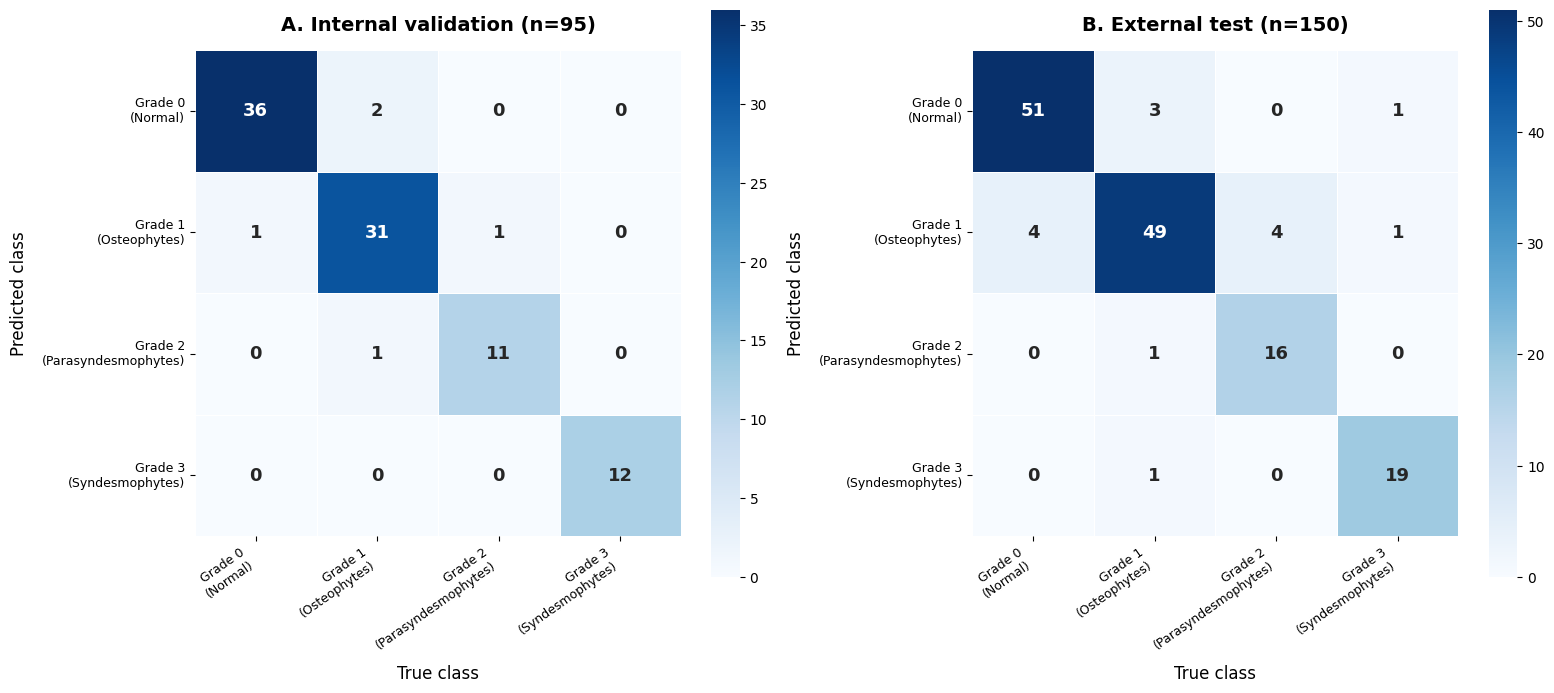

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

GRADE_LABELS = [f'Grade {i}\n({GRADE_TO_NAME[i]})' for i in range(N_CLASSES)]


def plot_cm(df, ax, title):
    cm = confusion_matrix(df['true_label'].values, df['pred_label'].values,
                          labels=list(range(N_CLASSES)))
    # Convention: rows = Predicted, cols = True (zgodnie z Twoimi poprzednimi figurami)
    sns.heatmap(cm.T, annot=True, fmt='d', cmap='Blues',
                xticklabels=GRADE_LABELS, yticklabels=GRADE_LABELS,
                cbar=True, ax=ax, annot_kws={'size': 13, 'weight': 'bold'},
                linewidths=0.5, linecolor='white', square=True)
    ax.set_title(title, fontsize=14, pad=14, weight='bold')
    ax.set_xlabel('True class', fontsize=12, labelpad=10)
    ax.set_ylabel('Predicted class', fontsize=12, labelpad=10)
    ax.set_xticklabels(GRADE_LABELS, rotation=35, ha='right', fontsize=9)
    ax.set_yticklabels(GRADE_LABELS, rotation=0, fontsize=9)
    return cm


fig, axes = plt.subplots(1, 2, figsize=(16, 7))
cm_int = plot_cm(df_internal, axes[0], f'A. Internal validation (n={len(df_internal)})')
cm_ext = plot_cm(df_external, axes[1], f'B. External test (n={len(df_external)})')
plt.tight_layout()
plt.savefig('/content/results/fig1_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.savefig('/content/results/fig1_confusion_matrices.tiff', dpi=300, bbox_inches='tight')
plt.show()

# Save raw CMs as CSV too
pd.DataFrame(cm_int, index=[f'true_grade_{i}' for i in range(N_CLASSES)],
             columns=[f'pred_grade_{i}' for i in range(N_CLASSES)]).to_csv('/content/results/cm_internal.csv')
pd.DataFrame(cm_ext, index=[f'true_grade_{i}' for i in range(N_CLASSES)],
             columns=[f'pred_grade_{i}' for i in range(N_CLASSES)]).to_csv('/content/results/cm_external.csv')

## Step 8 — Overall metrics with bootstrap 95% CI (Table 2)

In [ ]:
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                              f1_score, cohen_kappa_score)

N_BOOTSTRAP = 2000
RANDOM_SEED = 42


def overall_metrics_dict(df):
    yt = df['true_label'].values.astype(float)
    yp = df['pred_label'].values.astype(float)
    return {
        'accuracy': accuracy_score(yt, yp),
        'balanced_accuracy': balanced_accuracy_score(yt, yp),
        'macro_f1': f1_score(yt, yp, average='macro', zero_division=0),
        'weighted_kappa': cohen_kappa_score(yt, yp, weights='quadratic'),
        'mae': float(np.mean(np.abs(yt - yp))),
        'within_1_acc': float(np.mean(np.abs(yt - yp) <= 1)),
    }


def bootstrap_metrics(df, metric_fn, n_boot=N_BOOTSTRAP, seed=RANDOM_SEED):
    """Image-level bootstrap (1 image = 1 patient in this dataset)."""
    rng = np.random.default_rng(seed)
    n = len(df)
    point = metric_fn(df)
    is_dict = isinstance(point, dict)

    boots = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        try:
            boots.append(metric_fn(df.iloc[idx]))
        except Exception:
            continue

    if is_dict:
        out = {}
        for k in point.keys():
            vals = np.array([b[k] for b in boots
                             if not (isinstance(b[k], float) and np.isnan(b[k]))])
            if len(vals) == 0:
                out[k] = (point[k], np.nan, np.nan)
            else:
                lo, hi = np.percentile(vals, [2.5, 97.5])
                out[k] = (point[k], lo, hi)
        return out
    else:
        vals = np.array([b for b in boots if not (isinstance(b, float) and np.isnan(b))])
        if len(vals) == 0:
            return (point, np.nan, np.nan)
        lo, hi = np.percentile(vals, [2.5, 97.5])
        return (point, lo, hi)


def fmt_ci(point, lo, hi, d=3):
    if np.isnan(point):
        return 'NA'
    return f'{point:.{d}f} ({lo:.{d}f}–{hi:.{d}f})'


print('Computing overall metrics with bootstrap (kilka minut)...')
rows = []
for df_c, name in [(df_internal, 'Internal validation'),
                    (df_external, 'External test')]:
    results = bootstrap_metrics(df_c, overall_metrics_dict)
    for metric, (p, lo, hi) in results.items():
        rows.append({'Cohort': name, 'Metric': metric, 'Estimate (95% CI)': fmt_ci(p, lo, hi)})

table_overall = pd.DataFrame(rows)
table_overall.to_csv('/content/results/table2_overall_metrics.csv', index=False)
print(table_overall.to_string(index=False))

Computing overall metrics with bootstrap (kilka minut)...
             Cohort            Metric   Estimate (95% CI)
Internal validation          accuracy 0.947 (0.895–0.989)
Internal validation balanced_accuracy 0.950 (0.897–0.991)
Internal validation          macro_f1 0.951 (0.897–0.988)
Internal validation    weighted_kappa 0.974 (0.944–0.995)
Internal validation               mae 0.053 (0.011–0.105)
Internal validation      within_1_acc 1.000 (1.000–1.000)
      External test          accuracy 0.900 (0.847–0.947)
      External test balanced_accuracy 0.885 (0.819–0.941)
      External test          macro_f1 0.898 (0.837–0.944)
      External test    weighted_kappa 0.907 (0.825–0.963)
      External test               mae 0.127 (0.067–0.207)
      External test      within_1_acc 0.980 (0.953–1.000)


## Step 9 — Per-class metrics with 95% CI (Table 3)

In [ ]:
def per_class_metrics_dict(df, class_idx):
    yt = (df['true_label'].values == class_idx).astype(int)
    yp = (df['pred_label'].values == class_idx).astype(int)
    tp = int(((yt==1)&(yp==1)).sum())
    tn = int(((yt==0)&(yp==0)).sum())
    fp = int(((yt==0)&(yp==1)).sum())
    fn = int(((yt==1)&(yp==0)).sum())
    sens = tp/(tp+fn) if (tp+fn)>0 else np.nan
    spec = tn/(tn+fp) if (tn+fp)>0 else np.nan
    ppv = tp/(tp+fp) if (tp+fp)>0 else np.nan
    npv = tn/(tn+fn) if (tn+fn)>0 else np.nan
    f1 = (2*ppv*sens/(ppv+sens)
          if (not np.isnan(ppv) and not np.isnan(sens) and (ppv+sens)>0)
          else np.nan)
    return {'sensitivity': sens, 'specificity': spec,
            'ppv': ppv, 'npv': npv, 'f1': f1}


print('Computing per-class metrics with bootstrap...')
rows = []
for df_c, name in [(df_internal, 'Internal'), (df_external, 'External')]:
    for grade in range(N_CLASSES):
        res = bootstrap_metrics(df_c, lambda d, g=grade: per_class_metrics_dict(d, g))
        rows.append({
            'Cohort': name,
            'Grade': grade,
            'Class': GRADE_TO_NAME[grade],
            'N (true)': int((df_c['true_label'] == grade).sum()),
            'Sensitivity (95% CI)': fmt_ci(*res['sensitivity']),
            'Specificity (95% CI)': fmt_ci(*res['specificity']),
            'PPV (95% CI)': fmt_ci(*res['ppv']),
            'NPV (95% CI)': fmt_ci(*res['npv']),
            'F1 (95% CI)': fmt_ci(*res['f1']),
        })

table_perclass = pd.DataFrame(rows)
table_perclass.to_csv('/content/results/table3_per_class.csv', index=False)
print(table_perclass.to_string(index=False))

Computing per-class metrics with bootstrap...
  Cohort  Grade              Class  N (true) Sensitivity (95% CI) Specificity (95% CI)        PPV (95% CI)        NPV (95% CI)         F1 (95% CI)
Internal      0             Normal        37  0.973 (0.909–1.000)  0.966 (0.909–1.000) 0.947 (0.861–1.000) 0.982 (0.943–1.000) 0.960 (0.901–1.000)
Internal      1        Osteophytes        34  0.912 (0.806–1.000)  0.967 (0.914–1.000) 0.939 (0.850–1.000) 0.952 (0.887–1.000) 0.925 (0.849–0.984)
Internal      2 Parasyndesmophytes        12  0.917 (0.727–1.000)  0.988 (0.963–1.000) 0.917 (0.722–1.000) 0.988 (0.962–1.000) 0.917 (0.769–1.000)
Internal      3     Syndesmophytes        12  1.000 (1.000–1.000)  1.000 (1.000–1.000) 1.000 (1.000–1.000) 1.000 (1.000–1.000) 1.000 (1.000–1.000)
External      0             Normal        55  0.927 (0.855–0.983)  0.958 (0.913–0.990) 0.927 (0.852–0.983) 0.958 (0.914–0.990) 0.927 (0.871–0.972)
External      1        Osteophytes        54  0.907 (0.820–0.979)  0.906

## Step 10 — Generate ROC curves with AUC (per-class, one-vs-rest)

Generating ROC curves for internal validation...


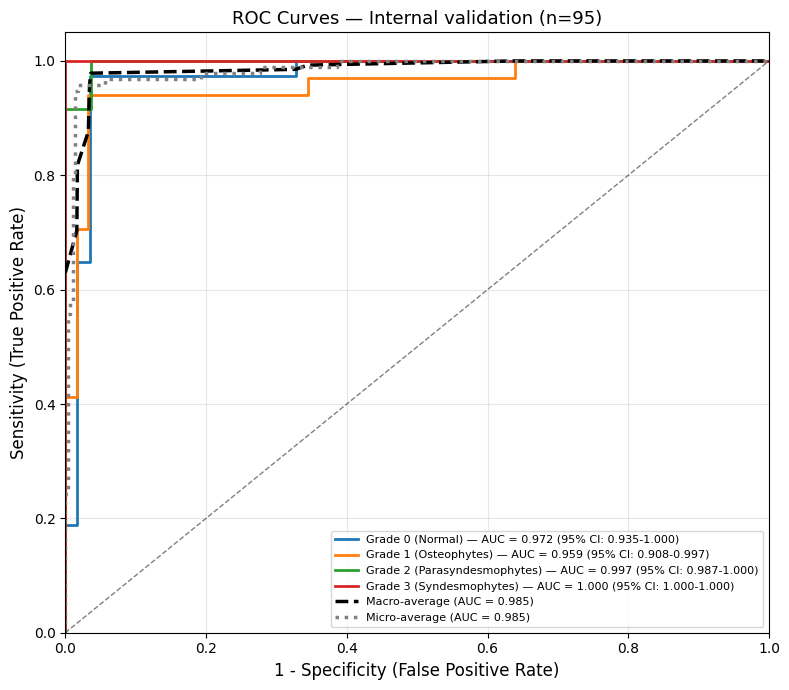


Generating ROC curves for external test...


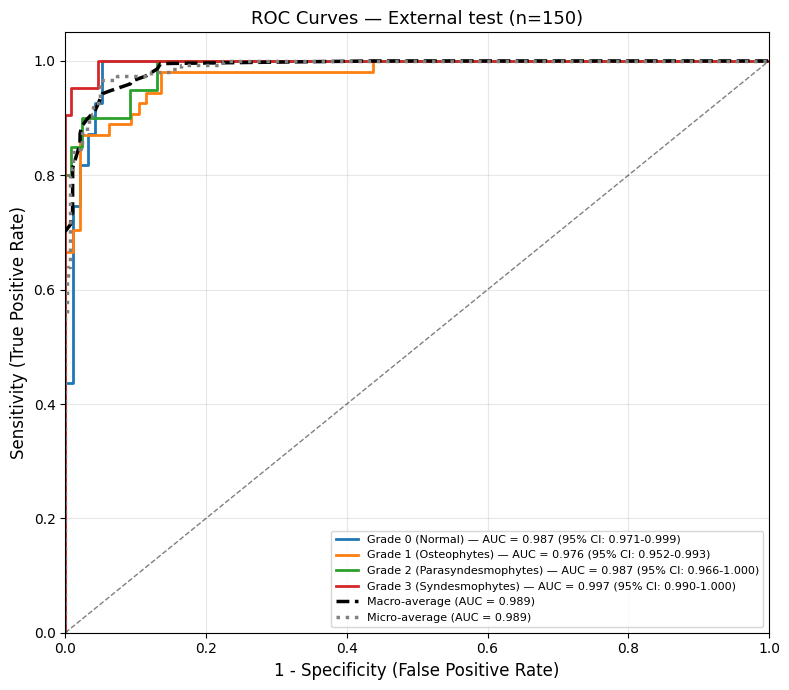


=== AUC Summary ===
Class           Internal AUC                        External AUC                       
Grade 0 (Normal    ) 0.972 (0.935-1.000)                 0.987 (0.971-0.999)                
Grade 1 (Osteophyte) 0.959 (0.908-0.997)                 0.976 (0.952-0.993)                
Grade 2 (Parasyndes) 0.997 (0.987-1.000)                 0.987 (0.966-1.000)                
Grade 3 (Syndesmoph) 1.000 (1.000-1.000)                 0.997 (0.990-1.000)                
Macro           0.985                               0.989                              
Micro           0.985                               0.989                              


In [ ]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from scipy import stats


def bootstrap_auc_ci(y_true_bin, y_scores, n_bootstrap=1000, seed=42):
    np.random.seed(seed)
    n = len(y_true_bin)
    aucs = []
    for _ in range(n_bootstrap):
        idx = np.random.choice(n, n, replace=True)
        if len(np.unique(y_true_bin[idx])) < 2:
            continue
        try:
            aucs.append(roc_auc_score(y_true_bin[idx], y_scores[idx]))
        except:
            continue
    if len(aucs) == 0:
        return (np.nan, np.nan)
    return np.percentile(aucs, [2.5, 97.5])


def plot_roc_multiclass(df, split_name, save_path_base):
    y_true = df['true_label'].values
    y_scores = df[[f'prob_grade_{i}' for i in range(N_CLASSES)]].values
    y_true_bin = label_binarize(y_true, classes=list(range(N_CLASSES)))

    fpr, tpr, roc_auc, ci = {}, {}, {}, {}
    for i in range(N_CLASSES):
        if y_true_bin[:, i].sum() == 0:
            continue
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        ci_low, ci_high = bootstrap_auc_ci(y_true_bin[:, i], y_scores[:, i])
        ci[i] = (ci_low, ci_high)

    fpr['micro'], tpr['micro'], _ = roc_curve(y_true_bin.ravel(), y_scores.ravel())
    roc_auc['micro'] = auc(fpr['micro'], tpr['micro'])

    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(N_CLASSES) if i in fpr]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(N_CLASSES):
        if i in fpr:
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= N_CLASSES
    fpr['macro'] = all_fpr
    tpr['macro'] = mean_tpr
    roc_auc['macro'] = auc(fpr['macro'], tpr['macro'])

    fig, ax = plt.subplots(figsize=(8, 7))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    for i in range(N_CLASSES):
        if i in fpr:
            label = (f'Grade {i} ({GRADE_TO_NAME[i]}) — AUC = {roc_auc[i]:.3f} '
                     f'(95% CI: {ci[i][0]:.3f}-{ci[i][1]:.3f})')
            ax.plot(fpr[i], tpr[i], color=colors[i], lw=2, label=label)

    ax.plot(fpr['macro'], tpr['macro'], color='black', lw=2.5, linestyle='--',
            label=f'Macro-average (AUC = {roc_auc["macro"]:.3f})')
    ax.plot(fpr['micro'], tpr['micro'], color='gray', lw=2.5, linestyle=':',
            label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('1 - Specificity (False Positive Rate)', fontsize=12)
    ax.set_ylabel('Sensitivity (True Positive Rate)', fontsize=12)
    ax.set_title(f'ROC Curves — {split_name.capitalize()} (n={len(df)})', fontsize=13)
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{save_path_base}.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'{save_path_base}.tiff', dpi=300, bbox_inches='tight')
    plt.show()

    return roc_auc, ci


print('Generating ROC curves for internal validation...')
auc_int, ci_int = plot_roc_multiclass(df_internal, 'internal validation',
                                       '/content/results/roc_curves_internal')

print('\nGenerating ROC curves for external test...')
auc_ext, ci_ext = plot_roc_multiclass(df_external, 'external test',
                                       '/content/results/roc_curves_external')

print('\n=== AUC Summary ===')
print(f'{"Class":<15} {"Internal AUC":<35} {"External AUC":<35}')
for i in range(N_CLASSES):
    int_str = (f'{auc_int[i]:.3f} ({ci_int[i][0]:.3f}-{ci_int[i][1]:.3f})'
               if i in auc_int else 'N/A')
    ext_str = (f'{auc_ext[i]:.3f} ({ci_ext[i][0]:.3f}-{ci_ext[i][1]:.3f})'
               if i in auc_ext else 'N/A')
    print(f'Grade {i} ({GRADE_TO_NAME[i][:10]:<10}) {int_str:<35} {ext_str:<35}')
print(f'{"Macro":<15} {auc_int["macro"]:<35.3f} {auc_ext["macro"]:<35.3f}')
print(f'{"Micro":<15} {auc_int["micro"]:<35.3f} {auc_ext["micro"]:<35.3f}')

## Step 11 — Binary clinical task: axSpA-related (grade 2+3) vs no axSpA-related (grade 0+1)

To **kluczowe clinical question paperu** — różnicowanie obecności zmian zapalnych axSpA (para+syndes) od ich braku (normal+osteo).

Binary clinical task analysis...
  Cohort Prevalence        AUC (95% CI) Youden threshold Sens at Youden Spec at Youden PPV at Youden NPV at Youden Threshold@90%sens Spec@90%sens
Internal      0.253 0.997 (0.988-1.000)            0.584          0.958          1.000         1.000         0.986             0.584        1.000
External      0.273 0.990 (0.975-0.999)            0.099          0.951          0.954         0.886         0.981             0.165        0.963


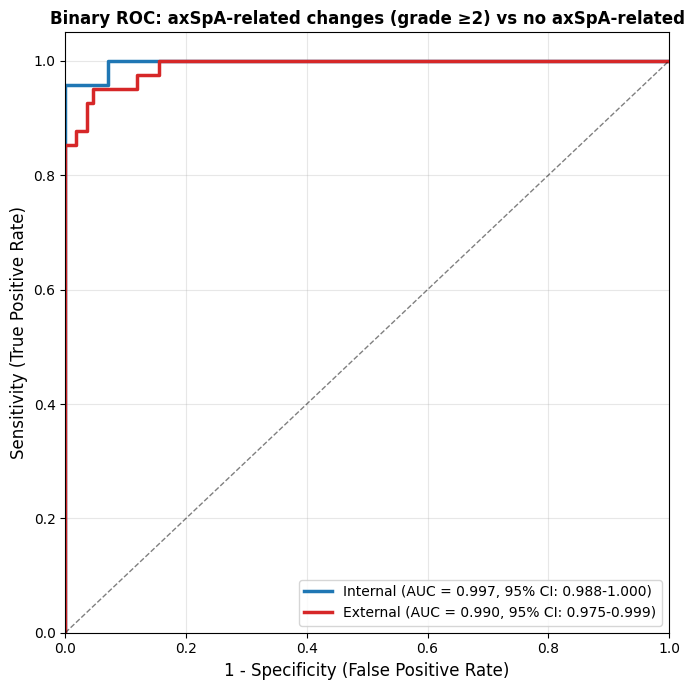

In [ ]:
def binary_clinical_analysis(df, split_name):   # ← usuń argument save_path
    # Define axSpA-related as grade ≥2 (parasyndesmophytes or syndesmophytes)
    y_true = (df['true_label'].values >= 2).astype(int)
    # P(axSpA-related) = P(grade 2) + P(grade 3)
    y_score = (df['prob_grade_2'].values + df['prob_grade_3'].values)

    if len(np.unique(y_true)) < 2:
        return None

    auc_val = roc_auc_score(y_true, y_score)
    ci_low, ci_high = bootstrap_auc_ci(y_true, y_score)

    fpr, tpr, thr = roc_curve(y_true, y_score)

    # Youden's J optimum
    j_idx = int(np.argmax(tpr - fpr))
    j_thr = float(thr[j_idx])

    # High-sensitivity threshold (≥0.90)
    hs_candidates = np.where(tpr >= 0.90)[0]
    hs_thr = float(thr[hs_candidates[0]]) if len(hs_candidates) > 0 else np.nan

    def metrics_at(threshold):
        yp = (y_score >= threshold).astype(int)
        tp = int(((y_true==1)&(yp==1)).sum())
        tn = int(((y_true==0)&(yp==0)).sum())
        fp = int(((y_true==0)&(yp==1)).sum())
        fn = int(((y_true==1)&(yp==0)).sum())
        return {
            'sens': tp/(tp+fn) if (tp+fn)>0 else np.nan,
            'spec': tn/(tn+fp) if (tn+fp)>0 else np.nan,
            'ppv': tp/(tp+fp) if (tp+fp)>0 else np.nan,
            'npv': tn/(tn+fn) if (tn+fn)>0 else np.nan,
        }

    y_m = metrics_at(j_thr)
    hs_m = metrics_at(hs_thr) if not np.isnan(hs_thr) else None

    return {
        'split': split_name,
        'prevalence': float(y_true.mean()),
        'auc': auc_val,
        'auc_ci': (ci_low, ci_high),
        'youden_thr': j_thr,
        'youden_metrics': y_m,
        'hs_thr': hs_thr,
        'hs_metrics': hs_m,
        'roc': (fpr, tpr),
    }


print('Binary clinical task analysis...')
binary_int = binary_clinical_analysis(df_internal, 'Internal')
binary_ext = binary_clinical_analysis(df_external, 'External')

# Build summary table
rows = []
for b in [binary_int, binary_ext]:
    if b is None: continue
    rows.append({
        'Cohort': b['split'],
        'Prevalence': f'{b["prevalence"]:.3f}',
        'AUC (95% CI)': f'{b["auc"]:.3f} ({b["auc_ci"][0]:.3f}-{b["auc_ci"][1]:.3f})',
        'Youden threshold': f'{b["youden_thr"]:.3f}',
        'Sens at Youden': f'{b["youden_metrics"]["sens"]:.3f}',
        'Spec at Youden': f'{b["youden_metrics"]["spec"]:.3f}',
        'PPV at Youden': f'{b["youden_metrics"]["ppv"]:.3f}',
        'NPV at Youden': f'{b["youden_metrics"]["npv"]:.3f}',
        'Threshold@90%sens': f'{b["hs_thr"]:.3f}' if b["hs_metrics"] else 'NA',
        'Spec@90%sens': f'{b["hs_metrics"]["spec"]:.3f}' if b["hs_metrics"] else 'NA',
    })

table_binary = pd.DataFrame(rows)
table_binary.to_csv('/content/results/table4_binary_clinical.csv', index=False)
print(table_binary.to_string(index=False))

# Plot binary ROC
fig, ax = plt.subplots(figsize=(7, 7))
for b, color in [(binary_int, '#1f77b4'), (binary_ext, '#d62728')]:
    if b is None: continue
    fpr, tpr = b['roc']
    ax.plot(fpr, tpr, lw=2.5,
            label=f'{b["split"]} (AUC = {b["auc"]:.3f}, 95% CI: {b["auc_ci"][0]:.3f}-{b["auc_ci"][1]:.3f})',
            color=color)
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
ax.set_xlabel('1 - Specificity (False Positive Rate)', fontsize=12)
ax.set_ylabel('Sensitivity (True Positive Rate)', fontsize=12)
ax.set_title('Binary ROC: axSpA-related changes (grade ≥2) vs no axSpA-related',
             fontsize=12, weight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/results/fig_binary_roc.png', dpi=300, bbox_inches='tight')
plt.savefig('/content/results/fig_binary_roc.tiff', dpi=300, bbox_inches='tight')
plt.show()

## Step 12 — Calibration analysis

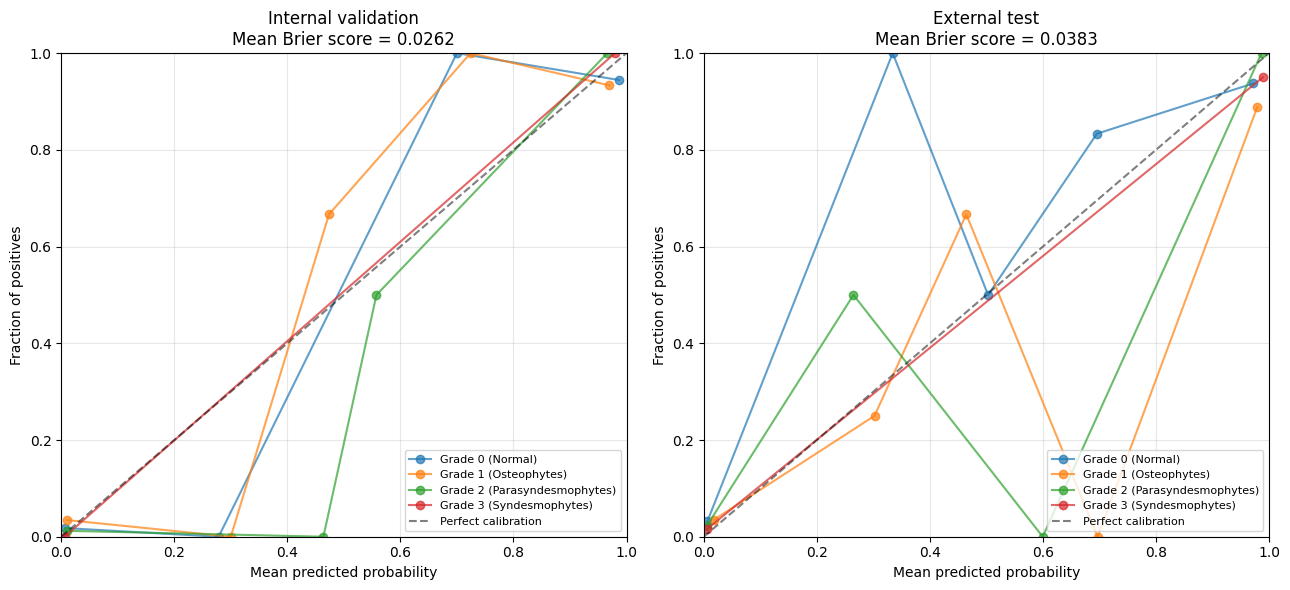


Brier scores (lower = better calibration):
  Internal: 0.0262
  External: 0.0383


In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss


def plot_calibration(df, split_name, ax):
    y_true = df['true_label'].values
    y_scores = df[[f'prob_grade_{i}' for i in range(N_CLASSES)]].values
    y_true_bin = label_binarize(y_true, classes=list(range(N_CLASSES)))

    brier_scores = []
    for i in range(N_CLASSES):
        if y_true_bin[:, i].sum() == 0:
            continue
        n_bins = min(5, max(2, int(y_true_bin[:, i].sum() / 3)))
        prob_true, prob_pred = calibration_curve(y_true_bin[:, i], y_scores[:, i],
                                                  n_bins=n_bins, strategy='uniform')
        ax.plot(prob_pred, prob_true, marker='o', linewidth=1.5,
                label=f'Grade {i} ({GRADE_TO_NAME[i]})', alpha=0.7)
        brier_scores.append(brier_score_loss(y_true_bin[:, i], y_scores[:, i]))

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    mean_brier = np.mean(brier_scores) if brier_scores else np.nan
    ax.set_title(f'{split_name}\nMean Brier score = {mean_brier:.4f}')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    return mean_brier


fig, axes = plt.subplots(1, 2, figsize=(13, 6))
brier_int = plot_calibration(df_internal, 'Internal validation', axes[0])
brier_ext = plot_calibration(df_external, 'External test', axes[1])
plt.tight_layout()
plt.savefig('/content/results/calibration_plots.png', dpi=300, bbox_inches='tight')
plt.savefig('/content/results/calibration_plots.tiff', dpi=300, bbox_inches='tight')
plt.show()

print(f'\nBrier scores (lower = better calibration):')
print(f'  Internal: {brier_int:.4f}')
print(f'  External: {brier_ext:.4f}')

## Step 13 — Safety analysis (critical misclassifications)

In [ ]:
def safety_analysis(df, split_name):
    rows = {'Cohort': split_name}
    # Advanced disease (grade 3) called normal (grade 0) — clinically worst
    g3 = df[df['true_label']==3]
    g0 = df[df['true_label']==0]
    g2 = df[df['true_label']==2]
    g1 = df[df['true_label']==1]
    axspa = df[df['true_label']>=2]

    rows['Advanced (grade 3) → normal (grade 0)'] = f'{int((g3["pred_label"]==0).sum())}/{len(g3)}'
    rows['Normal → advanced (grade 3)'] = f'{int((g0["pred_label"]==3).sum())}/{len(g0)}'
    rows['Any axSpA-related (≥2) → normal'] = f'{int((axspa["pred_label"]==0).sum())}/{len(axspa)}'
    rows['Para → osteo (clinical confusion)'] = f'{int((g2["pred_label"]==1).sum())}/{len(g2)}'
    rows['Osteo → para'] = f'{int((g1["pred_label"]==2).sum())}/{len(g1)}'
    return rows


safety_rows = [safety_analysis(df_internal, 'Internal'),
               safety_analysis(df_external, 'External')]
table_safety = pd.DataFrame(safety_rows)
table_safety.to_csv('/content/results/table5_safety.csv', index=False)
print(table_safety.to_string(index=False))

  Cohort Advanced (grade 3) → normal (grade 0) Normal → advanced (grade 3) Any axSpA-related (≥2) → normal Para → osteo (clinical confusion) Osteo → para
Internal                                  0/12                        0/37                            0/24                              1/12         1/34
External                                  1/21                        0/55                            1/41                              4/20         1/54


## Step 14 — Eigen-CAM visualizations (10 correct + 3 misclassified per grade)

**Wersja ulepszona** względem v1: użycie `YOLOClassificationWrapper` (YOLO zwraca tuple, Grad-CAM oczekuje tensora), automatyczne wykrycie ostatniej warstwy Conv2d, 640×640 z cv2.

In [ ]:
from pytorch_grad_cam import EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import cv2
import torch.nn as nn

os.makedirs('/content/results/gradcam_correct', exist_ok=True)
os.makedirs('/content/results/gradcam_misclassified', exist_ok=True)


class YOLOClassificationWrapper(nn.Module):
    """Wrapper: YOLO returns tuple, Grad-CAM expects tensor."""
    def __init__(self, yolo_model):
        super().__init__()
        self.model = yolo_model
    def forward(self, x):
        out = self.model(x)
        if isinstance(out, (list, tuple)):
            for item in out:
                if isinstance(item, torch.Tensor) and item.dim() >= 2:
                    return item
            return out[0]
        return out


# Setup wrapped model and CAM
torch_model = model.model.model
torch_model.eval()
wrapped_model = YOLOClassificationWrapper(torch_model)
wrapped_model.eval()
if torch.cuda.is_available():
    wrapped_model = wrapped_model.cuda()

target_layers = []
for module in torch_model.modules():
    if isinstance(module, torch.nn.Conv2d):
        target_layers = [module]

print(f'Target layer: {target_layers[0]}')
cam = EigenCAM(model=wrapped_model, target_layers=target_layers)


def generate_cam(img_path, true_label, pred_label, prob, save_path, is_error=False, cohort=''):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (640, 640))
    img_normalized = img_resized.astype(np.float32) / 255.0

    input_tensor = torch.from_numpy(img_normalized).permute(2, 0, 1).unsqueeze(0)
    if torch.cuda.is_available():
        input_tensor = input_tensor.cuda()

    try:
        grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0]
        cam_image = show_cam_on_image(img_normalized, grayscale_cam, use_rgb=True)
    except Exception as e:
        print(f'  CAM failed: {e}')
        return False

    true_name = GRADE_TO_NAME[true_label]
    pred_name = GRADE_TO_NAME[pred_label]

    fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
    axes[0].imshow(img_resized)
    title_left = f'Original\nTrue: Grade {true_label} ({true_name})'
    if cohort:
        title_left = f'Original — {cohort} cohort\nTrue: Grade {true_label} ({true_name})'
    axes[0].set_title(title_left, fontsize=11)
    axes[0].axis('off')

    axes[1].imshow(cam_image)
    if is_error:
        severity = abs(true_label - pred_label)
        sev_str = f'Error of {severity} grade{"s" if severity > 1 else ""}'
        axes[1].set_title(f'Eigen-CAM — MISCLASSIFIED\nPredicted: Grade {pred_label} ({pred_name}, p={prob:.2f}) — {sev_str}',
                          fontsize=11, color='darkred')
    else:
        axes[1].set_title(f'Eigen-CAM\nPredicted: Grade {pred_label} ({pred_name}, p={prob:.2f})',
                          fontsize=11)
    axes[1].axis('off')

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.close()
    return True


# ============================================================
# PART A — 10 CORRECT examples per grade (from external test)
# ============================================================
print('\n' + '='*60)
print(' PART A: CORRECT predictions (10 per grade)')
print('='*60)

examples_per_grade = 10
successful_correct = 0
external_path = os.path.join(extract_dir, external_split)

for grade in range(N_CLASSES):
    correct_df = df_external[(df_external['true_label'] == grade) &
                              (df_external['correct'] == 1)].copy()
    if len(correct_df) == 0:
        print(f'\nGrade {grade}: NO correct examples — skipping')
        continue

    correct_df['confidence'] = correct_df.apply(lambda r: r[f'prob_grade_{grade}'], axis=1)
    correct_df = correct_df.sort_values('confidence', ascending=False)
    selected = correct_df.head(examples_per_grade)

    print(f'\nGrade {grade} ({GRADE_TO_NAME[grade]}): generating {len(selected)} examples')
    for idx, row in selected.iterrows():
        img_path = os.path.join(external_path, row['folder'], row['image'])
        save_path = f'/content/results/gradcam_correct/grade_{grade}_example_{successful_correct}.png'
        if generate_cam(img_path, int(row['true_label']), int(row['pred_label']),
                        row['confidence'], save_path, is_error=False):
            successful_correct += 1
            print(f'  ✓ {row["image"]} (conf: {row["confidence"]:.3f})')

print(f'\nGenerated {successful_correct} CORRECT visualizations')


# ============================================================
# PART B — 3 MISCLASSIFIED examples per grade (combined cohorts)
# ============================================================
print('\n' + '='*60)
print(' PART B: MISCLASSIFIED predictions (3 per grade)')
print('='*60)

df_int_with_path = df_internal.copy()
df_int_with_path['source_path'] = df_int_with_path.apply(
    lambda r: os.path.join(extract_dir, internal_split, r['folder'], r['image']), axis=1)

df_ext_with_path = df_external.copy()
df_ext_with_path['source_path'] = df_ext_with_path.apply(
    lambda r: os.path.join(external_path, r['folder'], r['image']), axis=1)

df_combined = pd.concat([df_int_with_path, df_ext_with_path], ignore_index=True)

print('\nError summary across both cohorts:')
for grade in range(N_CLASSES):
    n_err = ((df_combined['true_label'] == grade) & (df_combined['correct'] == 0)).sum()
    print(f'  Grade {grade} ({GRADE_TO_NAME[grade]}) errors: {n_err}')

errors_per_grade = 3
successful_errors = 0

for true_grade in range(N_CLASSES):
    errors_df = df_combined[(df_combined['true_label'] == true_grade) &
                              (df_combined['correct'] == 0)].copy()

    if len(errors_df) == 0:
        print(f'\nGrade {true_grade}: NO ERRORS (perfect classification)')
        continue

    # Sort by confidence in WRONG prediction (most "confidently wrong" first)
    errors_df['wrong_pred_confidence'] = errors_df.apply(
        lambda r: r[f'prob_grade_{int(r["pred_label"])}'], axis=1)
    errors_df = errors_df.sort_values('wrong_pred_confidence', ascending=False)

    selected = errors_df.head(errors_per_grade)
    print(f'\nGrade {true_grade} ({GRADE_TO_NAME[true_grade]}): generating {len(selected)} error examples')

    for idx, row in selected.iterrows():
        img_path = row['source_path']
        true_lbl = int(row['true_label'])
        pred_lbl = int(row['pred_label'])
        wrong_conf = row['wrong_pred_confidence']
        cohort = row['split']

        save_name = f'error_true_{true_lbl}_pred_{pred_lbl}_{cohort}_example_{successful_errors}.png'
        save_path = f'/content/results/gradcam_misclassified/{save_name}'

        if generate_cam(img_path, true_lbl, pred_lbl, wrong_conf, save_path,
                        is_error=True, cohort=cohort):
            successful_errors += 1
            severity = abs(true_lbl - pred_lbl)
            sev_marker = '⚠️ SEVERE' if severity > 1 else 'adjacent'
            print(f'  ✓ {row["image"]} ({cohort}): true={true_lbl}, pred={pred_lbl}, '
                  f'p={wrong_conf:.3f} [{sev_marker}]')

print(f'\nGenerated {successful_errors} MISCLASSIFIED visualizations')
print(f'\nTotal: {successful_correct} correct + {successful_errors} errors = {successful_correct + successful_errors}')

Target layer: Conv2d(512, 1280, kernel_size=(1, 1), stride=(1, 1))

 PART A: CORRECT predictions (10 per grade)

Grade 0 (Normal): generating 10 examples
  ✓ 79.png (conf: 1.000)
  ✓ 94.png (conf: 1.000)
  ✓ 290.png (conf: 1.000)
  ✓ 44.png (conf: 1.000)
  ✓ 41.png (conf: 1.000)
  ✓ 22.png (conf: 1.000)
  ✓ 7.png (conf: 1.000)
  ✓ 176.png (conf: 1.000)
  ✓ 4.png (conf: 1.000)
  ✓ 1.png (conf: 1.000)

Grade 1 (Osteophytes): generating 10 examples
  ✓ 214.png (conf: 1.000)
  ✓ 188.png (conf: 1.000)
  ✓ 35.png (conf: 1.000)
  ✓ 190.png (conf: 1.000)
  ✓ 70.png (conf: 1.000)
  ✓ 130.png (conf: 1.000)
  ✓ 291.png (conf: 1.000)
  ✓ 259.png (conf: 1.000)
  ✓ 207.png (conf: 1.000)
  ✓ 38.png (conf: 1.000)

Grade 2 (Parasyndesmophytes): generating 10 examples
  ✓ 25.png (conf: 1.000)
  ✓ 18.png (conf: 1.000)
  ✓ 58.png (conf: 1.000)
  ✓ 49.png (conf: 1.000)
  ✓ 82.png (conf: 1.000)
  ✓ 36.png (conf: 1.000)
  ✓ 42.png (conf: 1.000)
  ✓ 76.png (conf: 1.000)
  ✓ 79.png (conf: 1.000)
  ✓ 78.png (co

## Step 15 — Save comprehensive metrics summary

In [ ]:
summary = {
    'metric': ['n_samples', 'accuracy', 'macro_AUC', 'micro_AUC', 'brier_score',
               'binary_AUC_axSpA_vs_not'] +
              [f'AUC_grade_{i}' for i in range(N_CLASSES)] +
              [f'AUC_grade_{i}_CI_low' for i in range(N_CLASSES)] +
              [f'AUC_grade_{i}_CI_high' for i in range(N_CLASSES)],
    'internal_validation': [
        len(df_internal),
        df_internal['correct'].mean(),
        auc_int['macro'],
        auc_int['micro'],
        brier_int,
        binary_int['auc'] if binary_int else np.nan,
    ] + [auc_int.get(i, np.nan) for i in range(N_CLASSES)] +
      [ci_int.get(i, (np.nan, np.nan))[0] for i in range(N_CLASSES)] +
      [ci_int.get(i, (np.nan, np.nan))[1] for i in range(N_CLASSES)],
    'external_test': [
        len(df_external),
        df_external['correct'].mean(),
        auc_ext['macro'],
        auc_ext['micro'],
        brier_ext,
        binary_ext['auc'] if binary_ext else np.nan,
    ] + [auc_ext.get(i, np.nan) for i in range(N_CLASSES)] +
      [ci_ext.get(i, (np.nan, np.nan))[0] for i in range(N_CLASSES)] +
      [ci_ext.get(i, (np.nan, np.nan))[1] for i in range(N_CLASSES)],
}

df_summary = pd.DataFrame(summary)
df_summary.to_csv('/content/results/metrics_summary.csv', index=False)
print(df_summary.to_string(index=False))

# Also write Excel with all tables
with pd.ExcelWriter('/content/results/all_tables.xlsx') as writer:
    table_overall.to_excel(writer, sheet_name='Table2_Overall', index=False)
    table_perclass.to_excel(writer, sheet_name='Table3_PerClass', index=False)
    table_binary.to_excel(writer, sheet_name='Table4_BinaryClinical', index=False)
    table_safety.to_excel(writer, sheet_name='Table5_Safety', index=False)
    df_summary.to_excel(writer, sheet_name='AUC_Summary', index=False)

print('\nAll tables exported to all_tables.xlsx')

                 metric  internal_validation  external_test
              n_samples            95.000000     150.000000
               accuracy             0.947368       0.900000
              macro_AUC             0.985216       0.988632
              micro_AUC             0.984561       0.988785
            brier_score             0.026175       0.038289
binary_AUC_axSpA_vs_not             0.997066       0.989931
            AUC_grade_0             0.972041       0.987368
            AUC_grade_1             0.958534       0.976080
            AUC_grade_2             0.996988       0.987308
            AUC_grade_3             1.000000       0.997416
     AUC_grade_0_CI_low             0.934871       0.970768
     AUC_grade_1_CI_low             0.908382       0.952080
     AUC_grade_2_CI_low             0.987013       0.965501
     AUC_grade_3_CI_low             1.000000       0.989730
    AUC_grade_0_CI_high             1.000000       0.998627
    AUC_grade_1_CI_high             0.99

## Step 16 — Download all results as ZIP

In [ ]:
import shutil
shutil.make_archive('/content/axspa_results', 'zip', '/content/results')

from google.colab import files
files.download('/content/axspa_results.zip')

print('\nDone! Pobranie ZIPa rozpocznie sie automatycznie.')
print('Zawartosc:')
for root, dirs, fs in os.walk('/content/results'):
    for f in fs:
        full_path = os.path.join(root, f)
        size_kb = os.path.getsize(full_path) / 1024
        print(f'  {full_path.replace("/content/results/", "")} ({size_kb:.1f} KB)')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done! Pobranie ZIPa rozpocznie sie automatycznie.
Zawartosc:
  fig1_confusion_matrices.png (272.3 KB)
  roc_curves_external.tiff (19050.7 KB)
  calibration_plots.tiff (26591.3 KB)
  table2_overall_metrics.csv (0.6 KB)
  softmax_probabilities_internal.csv (11.0 KB)
  cm_external.csv (0.1 KB)
  table5_safety.csv (0.2 KB)
  table4_binary_clinical.csv (0.3 KB)
  table3_per_class.csv (1.2 KB)
  fig_binary_roc.png (184.7 KB)
  fig_binary_roc.tiff (16753.8 KB)
  calibration_plots.png (545.3 KB)
  cm_internal.csv (0.1 KB)
  roc_curves_internal.tiff (19050.7 KB)
  roc_curves_internal.png (266.2 KB)
  softmax_probabilities_external.csv (17.3 KB)
  inference_time.json (0.2 KB)
  all_tables.xlsx (8.9 KB)
  fig1_confusion_matrices.tiff (37620.0 KB)
  roc_curves_external.png (265.5 KB)
  metrics_summary.csv (0.9 KB)
  gradcam_correct/grade_2_example_26.png (833.5 KB)
  gradcam_correct/grade_2_example_22.png (845.4 KB)
  gradcam_correct/grade_0_example_5.png (913.8 KB)
  gradcam_correct/grade_3_exam